# Modelo de Regresión

In [6]:
# --- 1️⃣ Librerías ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [5]:
df = pd.read_csv("Datos Modelos\consolidado_con_REM.csv")
df.columns
print(df.head())

  municipio   año  numcasos  ciclo_vital_adolescencia  ciclo_vital_adulto  \
0   BARANOA  2017         7                  0.000000            0.857143   
1   BARANOA  2018       162                  0.475309            0.111111   
2   BARANOA  2019       395                  0.518987            0.078481   
3   BARANOA  2020       170                  0.435294            0.100000   
4   BARANOA  2021       109                  0.550459            0.073394   

   ciclo_vital_adulto_mayor  ciclo_vital_ancianidad  ciclo_vital_infancia  \
0                  0.000000                0.000000              0.000000   
1                  0.018519                0.000000              0.277778   
2                  0.015190                0.002532              0.293671   
3                  0.017647                0.005882              0.341176   
4                  0.018349                0.009174              0.284404   

   ciclo_vital_menor_de_1_año  ciclo_vital_primera_infancia  ...  periodo_

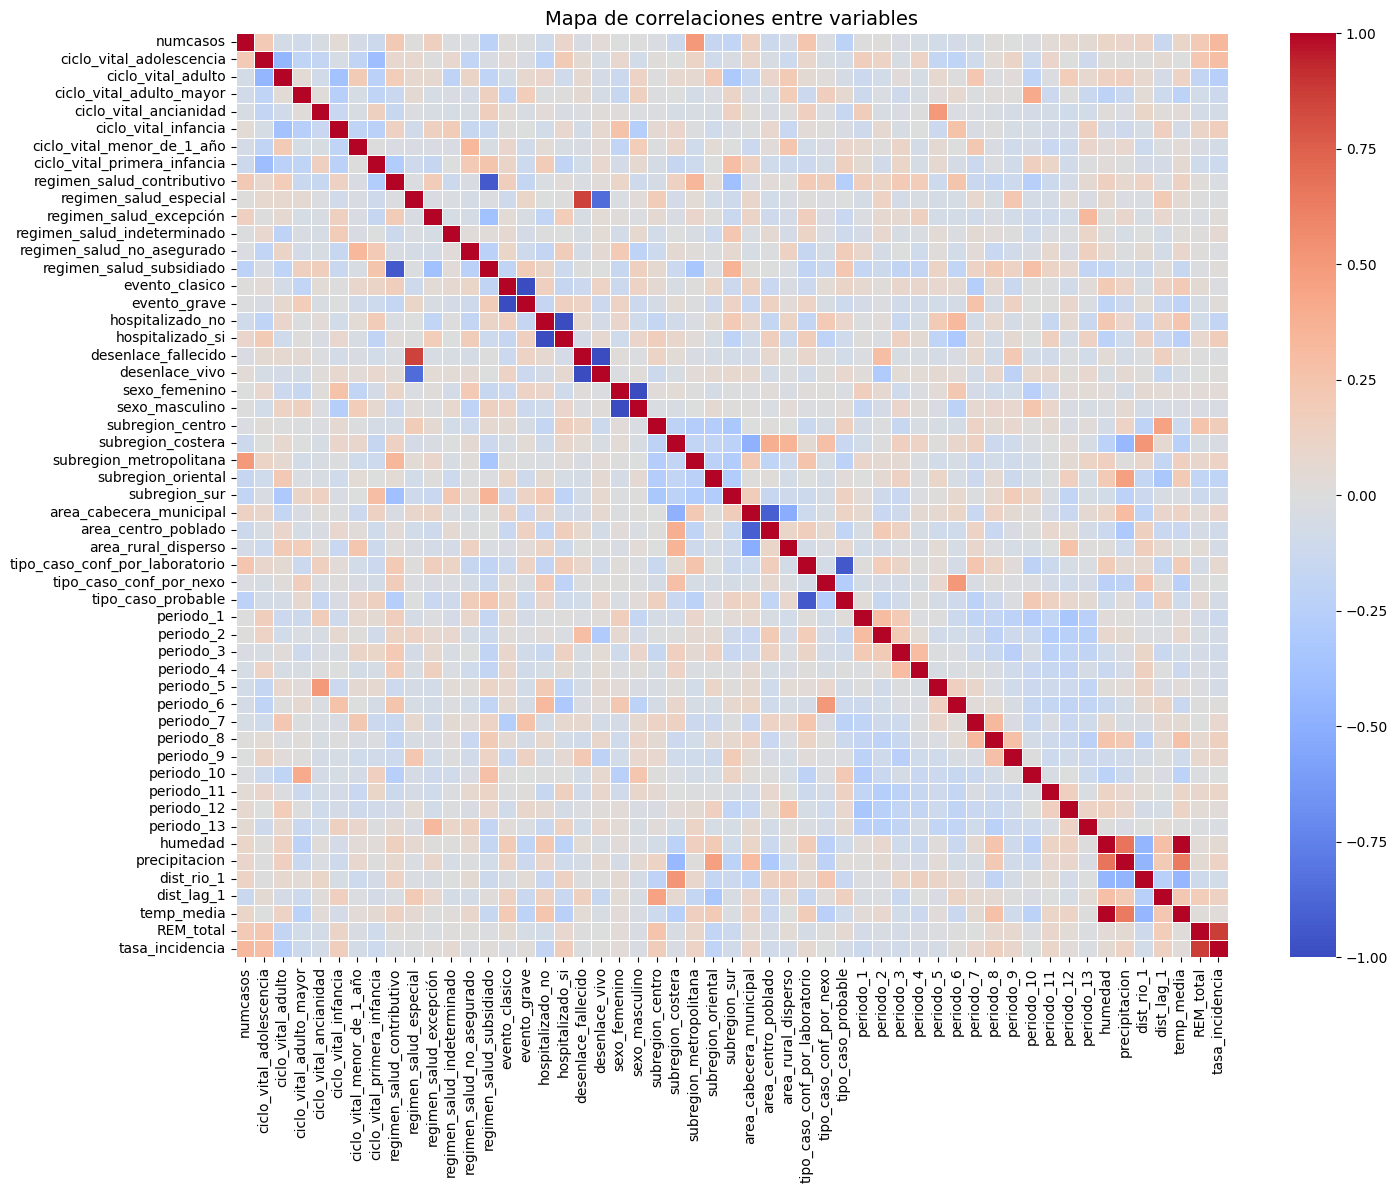


📊 Correlación de cada variable con REM_total
REM_total                         1.000000
tasa_incidencia                   0.867807
subregion_centro                  0.254945
ciclo_vital_adolescencia          0.230120
numcasos                          0.206894
dist_lag_1                        0.184975
ciclo_vital_infancia              0.112512
periodo_11                        0.086639
subregion_metropolitana           0.086452
hospitalizado_si                  0.082240
periodo_9                         0.074533
periodo_8                         0.067134
tipo_caso_probable                0.057021
evento_clasico                    0.053977
precipitacion                     0.052514
periodo_12                        0.046692
area_rural_disperso               0.039332
area_cabecera_municipal           0.035375
sexo_femenino                     0.034895
humedad                           0.032423
regimen_salud_contributivo        0.018795
temp_media                        0.016883
regimen_

C:\Users\TAWTOCA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [10]:
# --- 1️⃣ Librerías ---

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


# --- 3️⃣ Definir columnas numéricas para análisis ---
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Quitamos identificadores
cols_numericas = [c for c in cols_numericas if c not in ["año", "poblacion"]]

# --- 4️⃣ Matriz de correlación completa ---
corr = df[cols_numericas].corr()

# --- 5️⃣ Mapa de calor general ---
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Mapa de correlaciones entre variables", fontsize=14)
plt.show()

# --- 6️⃣ Correlaciones con la variable objetivo ---
objetivo = "REM_total"  # Cambiar según la variable objetivo
corr_obj = corr[objetivo].sort_values(ascending=False)

print("\n📊 Correlación de cada variable con", objetivo)
print(corr_obj)

# --- 7️⃣ Identificar pares de variables muy correlacionadas (|r| > 0.85) ---
umbral = 0.85
pares_correlacion = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > umbral:
            pares_correlacion.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("\n⚠️ Variables muy correlacionadas (|r| > 0.85):")
for v1, v2, r in pares_correlacion:
    print(f"{v1} — {v2}: {r:.3f}")

# --- 8️⃣ Multicolinealidad (VIF) ---
# Seleccionamos variables numéricas sin la variable objetivo
X_vif = df[[c for c in cols_numericas if c != objetivo]].copy()

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n📈 Factores de Inflación de Varianza (VIF):")
print(vif_data.sort_values("VIF", ascending=False))


In [8]:


# --- 3️⃣ Definir variables predictoras (X) y variable objetivo (y) ---

#remplazar valores NaN con 0
df = df.fillna(0)
# Quitamos identificadores y variables derivadas de la salida
X = df.drop(columns=["municipio", "año", "tasa_incidencia", "REM_total"])
y = df["REM_total"]   # o puedes cambiar por "REM_total"

# --- 4️⃣ Separar datos en entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5️⃣ Entrenar el modelo ---
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# --- 6️⃣ Predicciones ---
y_pred = modelo.predict(X_test)

# --- 7️⃣ Evaluar desempeño ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 Evaluación del modelo lineal básico:")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# --- 8️⃣ Coeficientes del modelo ---
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", ascending=False)

print("\n📊 Coeficientes más influyentes:")
print(coeficientes.head(10))
print(coeficientes.tail(10))


🔹 Evaluación del modelo lineal básico:
R²: -0.201
MAE: 0.619
RMSE: 0.886

📊 Coeficientes más influyentes:
                      Variable  Coeficiente
12  regimen_salud_no_asegurado     5.431228
18         desenlace_fallecido     5.110161
8   regimen_salud_contributivo     3.341742
13    regimen_salud_subsidiado     2.957891
10     regimen_salud_excepción     1.900556
1     ciclo_vital_adolescencia     1.037657
37                   periodo_5     0.794741
5         ciclo_vital_infancia     0.786377
29         area_rural_disperso     0.767584
34                   periodo_2     0.642909
                          Variable  Coeficiente
20                   sexo_femenino    -0.423076
28             area_centro_poblado    -0.514082
3         ciclo_vital_adulto_mayor    -0.566036
30  tipo_caso_conf_por_laboratorio    -0.644859
33                       periodo_1    -0.778674
6       ciclo_vital_menor_de_1_año    -0.829307
2               ciclo_vital_adulto    -0.898967
36                       p